# House Price Prediction using Linear Regression

## SkillCraft Technology Internship

### Task 01 - Machine Learning

**Name:** N.S.Aishwarya

**Track Code:** ML

**Objective:**

Build a Linear Regression model to predict house prices based on:
- Square Footage
- Number of Bedrooms
- Number of Bathrooms

# Import Required Libraries

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
%matplotlib inline

# Load the Dataset

In [52]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Explore the Dataset

In [53]:
print("Dataset Shape:", df.shape)
df.info()
df.describe()

Dataset Shape: (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-nu

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [54]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

# Check Missing Values

In [55]:
missing_values = df.isnull().sum()
missing_values[missing_values > 0].sort_values(ascending=False)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageType,81
GarageYrBlt,81
GarageFinish,81


In [56]:
df[['GrLivArea','BedroomAbvGr','FullBath','SalePrice']].isnull().sum()

,0
GrLivArea,0
BedroomAbvGr,0
FullBath,0
SalePrice,0


In [57]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


# Feature Selection

In [58]:
X = df[['GrLivArea','BedroomAbvGr','FullBath']]
y = df['SalePrice']
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)
X.head()

Features Shape: (1460, 3)
Target Shape: (1460,)


,GrLivArea,BedroomAbvGr,FullBath
0,1710,3,2
1,1262,3,2
2,1786,3,2
3,1717,3,1
4,2198,4,2


# Split the Dataset

In [59]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)
print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (1168, 3)
Testing Features: (292, 3)
Training Target: (1168,)
Testing Target: (292,)


# Train the Linear Regression Model

In [60]:
model = LinearRegression()
model.fit(X_train,y_train)
print("Model trained successfully!")

Model trained successfully!


# Predict House Prices

In [61]:
y_pred = model.predict(X_test)
print(y_pred[:10])

[113410.67255298 305081.87775899 135904.78562983 205424.67564124
 227502.68349004 121157.48079629 205577.98056584 183787.20378269
 121157.48079629 147219.22233196]


In [62]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
comparison.head(10)

,Actual Price,Predicted Price
0,154500,113410.672553
1,325000,305081.877759
2,115000,135904.785630
3,159000,205424.675641
4,315500,227502.683490
5,75500,121157.480796
6,311500,205577.980566
7,146000,183787.203783
8,84500,121157.480796
9,135500,147219.222332


# Model Evaluation

In [63]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print("Mean Absolute Error:",mae)
print("Mean Squared Error:",mse)
print("Root Mean Squared Error:",rmse)
print("R² Score:",r2)

Mean Absolute Error: 35788.061292436294
Mean Squared Error: 2806426667.247853
Root Mean Squared Error: 52975.71771338122
R² Score: 0.6341189942328371


# Visualization 1 : Actual vs Predicted Prices

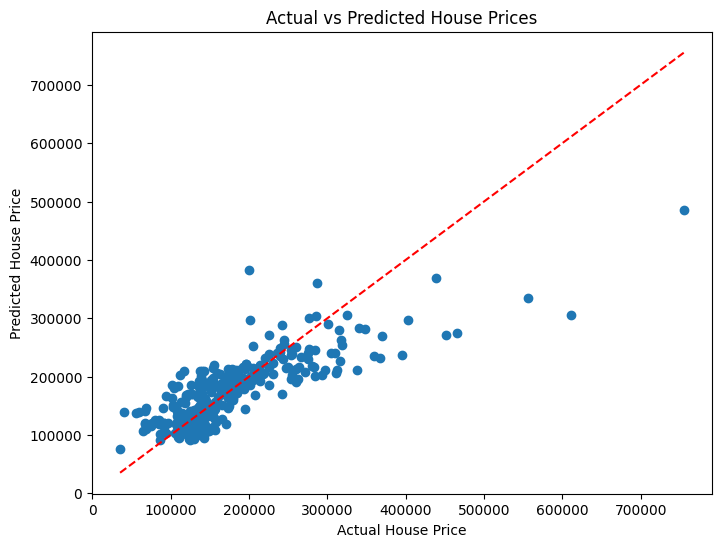

In [64]:
plt.figure(figsize=(8,6))
plt.scatter(y_test,y_pred)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    'r--'
)
plt.xlabel("Actual House Price")
plt.ylabel("Predicted House Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Visualization 2 : Residual Plot

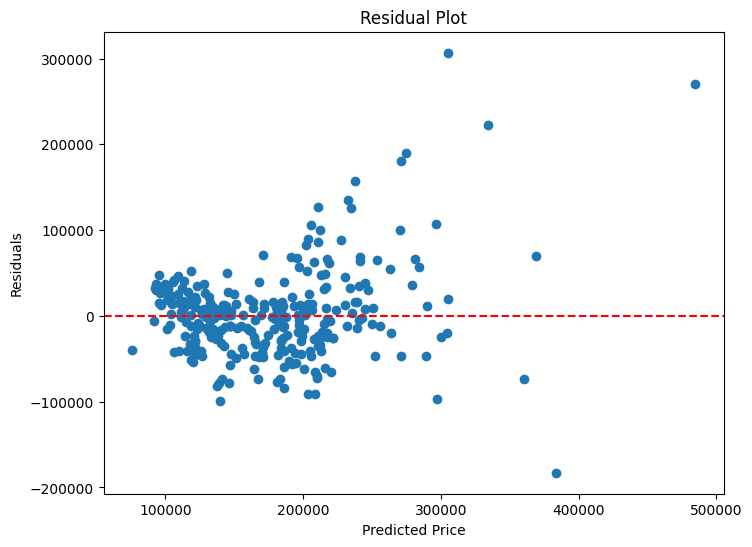

In [65]:
residuals = y_test-y_pred
plt.figure(figsize=(8,6))
plt.scatter(y_pred,residuals)
plt.axhline(y=0,color='red',linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# Visualization 3 : Correlation Heatmap

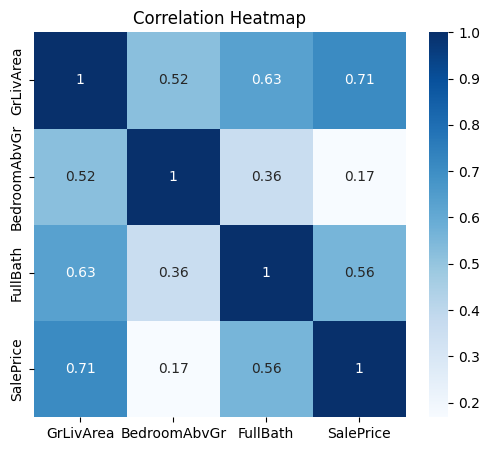

In [66]:
plt.figure(figsize=(6,5))
sns.heatmap(
    df[['GrLivArea','BedroomAbvGr','FullBath','SalePrice']].corr(),
    annot=True,
    cmap="Blues"
)
plt.title("Correlation Heatmap")
plt.show()

# Conclusion

A Linear Regression model was successfully developed to predict house prices using the following features:

- GrLivArea (Square Footage)
- BedroomAbvGr (Number of Bedrooms)
- FullBath (Number of Bathrooms)

The model achieved:

- MAE ≈ 35,788
- RMSE ≈ 52,976
- R² Score ≈ 0.634

The model demonstrates reasonable predictive performance using only three features. Incorporating additional features such as neighborhood, garage area, overall quality, and year built could further improve prediction accuracy.